In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

%load_ext autoreload
%autoreload 2

sys.path.insert(0, "..")
import plasmidtools


Paths

In [2]:
DATA_DIR = Path("../data")
FIG_DIR = DATA_DIR / "figures"
ADDGENE_DIR = DATA_DIR / "addgene"
MANUAL_DIR = DATA_DIR / "manual_annotations"
PILEUP_PATH = ADDGENE_DIR / "plasmid_elements_prediction_pileups.h5"


Pre-processed / pre-calculated data

In [3]:
plasmid_meta = pl.read_csv(ADDGENE_DIR / "mammalian_plasmids.tsv", separator="\t")
plasmid_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene.parquet")
plasmid_stats = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_statistics.parquet")


In [4]:
element_positions = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_elements.parquet")
element_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene_elements.parquet")
primer_positions = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_primers.parquet")
primer_citations = pl.read_parquet(ADDGENE_DIR / "citations_addgene_primers.parquet")

cre_annotation = pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_cre_and_tss.parquet")

element_cre_overlap = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_element_cre_overlaps.parquet")
    .join(element_citations[["element_type", "element_name", "n_plasmids", "n_citations"]], left_on=["type", "name"], right_on=["element_type", "element_name"], how="left")
    .with_columns(pl.max_horizontal("tss_fwd_avg_signal", "tss_rev_avg_signal").alias("tss_avg_signal"))
)

primer_cre_overlap = (
    pl.read_parquet(ADDGENE_DIR / "mammalian_plasmids_primers_cre_overlaps.parquet")
    .join(primer_citations[["element_type", "element_name", "n_plasmids", "n_citations"]], left_on=["type", "name"], right_on=["element_type", "element_name"], how="left")
    .with_columns(pl.max_horizontal("tss_fwd_avg_signal", "tss_rev_avg_signal").alias("tss_avg_signal"))
)


Manual annotations

In [5]:
promoters = pl.read_csv(MANUAL_DIR / "addgene_promoters_and_enhancers.csv")
mammalian_promoters = promoters.filter(pl.col("active_in_mammalian_cells") & (pl.col("RNA_polymerase") == "RNA Pol II"))
promoter_specificity = pl.read_csv(MANUAL_DIR / "addgene_promoters_specificity.csv")
promoter_predictions = pl.read_csv(ADDGENE_DIR / "promoter_activity_predictions.csv")


### Results

Calculations are made in the [`09_addgene_promoters.py`](../scripts/09_addgene_promoters.py) and [`13_element_pileups.py`](../scripts/13_element_pileups.py) scripts.

**1. Directionality of promoters**

Examples

In [6]:
element_type = "promoter"
un_promoter, bi_promoter = "SFFV promoter", "SV40 promoter"
element_name = un_promoter

(
    element_size, flank_size,
    type_matrix, cre_matrix, tss_fwd_matrix, tss_rev_matrix,
    pred_matrix, pred_fwd_matrix, pred_rev_matrix
) = plasmidtools.helpers.load_aligned_predictions_h5(element_type, element_name, PILEUP_PATH)

fig, (ax1, ax2) = plasmidtools.statplots.combined_prediction_pileups(pred_matrix, pred_fwd_matrix, pred_rev_matrix, element_type, element_name, flank_size)
ax2.set_ylim([-.6, .6])
plt.close()


Overall

In [7]:
direct_df = (
    mammalian_promoters
    .filter(pl.col("element_type") == "promoter")
    ["element_name", "directionality"]
    .join(promoter_predictions, on="element_name")
)


fig, ax = plt.subplots(figsize=(6, 6))

sns.scatterplot(
    data=direct_df.filter(pl.col("Puffin (FANTOM_CAGE_fwd)") < 3.5), 
    x="Puffin (FANTOM_CAGE_fwd)", 
    y="Puffin (FANTOM_CAGE_rev)", 
    hue="directionality",
    palette={"Unidirectional": "cornflowerblue", "Bidirectional": "firebrick"},
    edgecolor=None, alpha=0.8, s=40, zorder=2, ax=ax
)

label_df = (
    direct_df
    .filter(pl.col("Puffin (FANTOM_CAGE_fwd)") < 3.5)
    .filter(
        (pl.col("directionality") == "Bidirectional") |
        ((pl.col("Puffin (FANTOM_CAGE_fwd)") > 0.45) & (pl.col("Puffin (FANTOM_CAGE_rev)") > 0.45)) |
        (pl.col("Puffin (FANTOM_CAGE_fwd)") > 3)
    )
)

for row in label_df.iter_rows(named=True):
    name = row["element_name"]
    x, y = row["Puffin (FANTOM_CAGE_fwd)"], row["Puffin (FANTOM_CAGE_rev)"]
    if name == "SV40 promoter":
        ax.annotate(name, xy=(x, y), xytext=(x - 0.15, y - 0.15), fontsize=9, va="top", arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))
    else:
        ax.text(x + 0.05, y, name, fontsize=9)

ax.set_xlim([-.1, 3.5])
ax.set_ylim([-.1, 3.5])
ax.set_xlabel("Predicted CAGE Forward Signal", fontsize=12)
ax.set_ylabel("Predicted CAGE Reverse Signal", fontsize=12)

sns.despine()
ax.legend(title="Annotation", frameon=False)
plt.close()


**2. Promoter strength**

Divide into non-RNA Pol II / non-mammalian, weak, moderate, strong

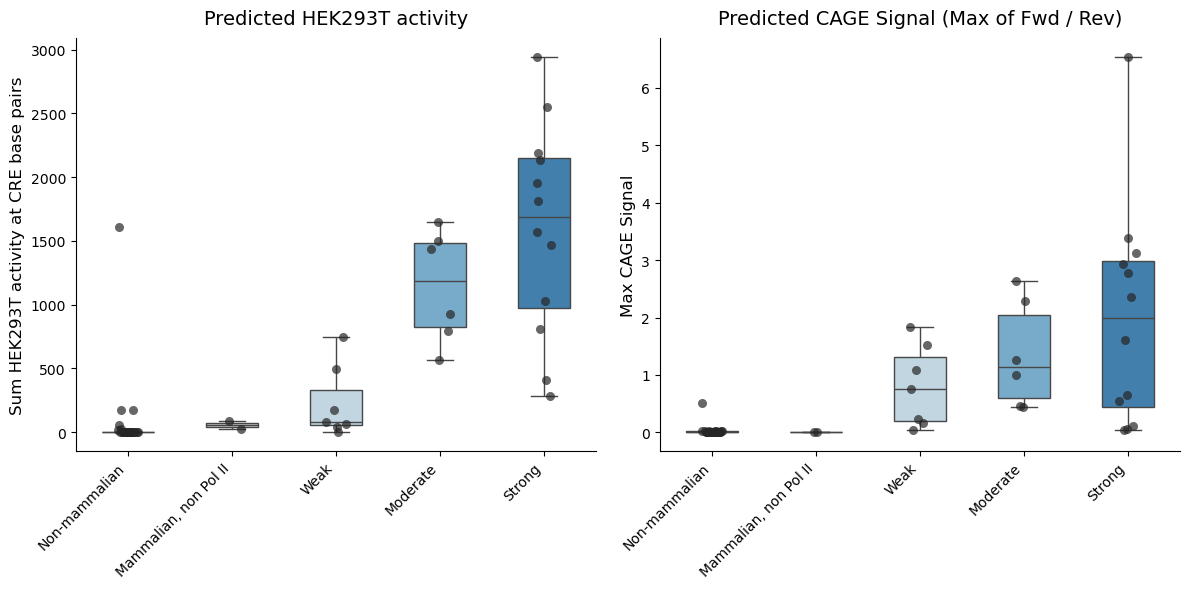

In [8]:
# 1. Join dataframes and compute categories and max CAGE signal
merged_df = promoters.join(promoter_predictions, on=["element_type", "element_name"], how="inner")

df_plot = merged_df.with_columns([
    pl.max_horizontal("Puffin (FANTOM_CAGE_fwd)", "Puffin (FANTOM_CAGE_rev)").alias("max_puff_cage"),
    pl.when(~pl.col("active_in_mammalian_cells"))
    .then(pl.lit("Non-mammalian"))
    .when(~pl.col("RNA_polymerase").is_in(["RNA Pol II", "RNA Pol II / RNA Pol III"]))
    .then(pl.lit("Mammalian, non Pol II"))
    .when((pl.col("regulation").is_in(["Constitutive", "Minimal"])) & (pl.col("strength") == "Weak"))
    .then(pl.lit("Weak"))
    .when((pl.col("regulation").is_in(["Constitutive", "Minimal"])) & (pl.col("strength") == "Moderate"))
    .then(pl.lit("Moderate"))
    .when((pl.col("regulation").is_in(["Constitutive", "Minimal"])) & (pl.col("strength") == "Strong"))
    .then(pl.lit("Strong"))
    .otherwise(pl.lit(None))
    .alias("category")
]).drop_nulls("category")

df_plot_pd = df_plot.to_pandas()

cat_order = ["Non-mammalian", "Mammalian, non Pol II", "Weak", "Moderate", "Strong"]

# 2. Define a muted, sequential color palette mapping to expected strength
palette = {
    "Non-mammalian": "#e5e5e5",         # light neutral gray
    "Mammalian, non Pol II": "#cccccc", # deeper neutral gray
    "Weak": "#bdd7e7",                  # soft, pale blue
    "Moderate": "#6baed6",              # muted medium blue
    "Strong": "#3182bd"                 # darker, solid blue
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 3. Left Plot: CREST (HEK293T)
# hue="category" and legend=False resolves the Seaborn palette FutureWarning
cell = "HEK293T"
sns.boxplot(
    data=df_plot_pd, x="category", y=f"CREST ({cell})", 
    order=cat_order, hue="category", palette=palette, legend=False,
    width=0.5, showfliers=False, ax=axes[0]
)
# Increased size=6.5 and adjusted alpha to make points the focal point
sns.stripplot(
    data=df_plot_pd, x="category", y=f"CREST ({cell})", 
    order=cat_order, color=".15", alpha=0.7, jitter=True, size=6.5, ax=axes[0]
)
axes[0].set_title(f"Predicted {cell} activity", fontsize=14, pad=10)
axes[0].set_ylabel(f"Sum {cell} activity at CRE base pairs", fontsize=12)

# 4. Right Plot: max_puff_cage
sns.boxplot(
    data=df_plot_pd, x="category", y="max_puff_cage", 
    order=cat_order, hue="category", palette=palette, legend=False,
    width=0.5, showfliers=False, ax=axes[1]
)
sns.stripplot(
    data=df_plot_pd, x="category", y="max_puff_cage", 
    order=cat_order, color=".15", alpha=0.7, jitter=True, size=6.5, ax=axes[1]
)
axes[1].set_title("Predicted CAGE Signal (Max of Fwd / Rev)", fontsize=14, pad=10)
axes[1].set_ylabel("Max CAGE Signal", fontsize=12)

# 5. Styling and layout
for ax in axes:
    ax.set_xlabel("")
    
    # Resolves the Matplotlib UserWarning by explicitly setting tick positions first
    ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels(cat_order, rotation=45, ha="right")
    
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


**3. Tissue specificity**

CREST predictions are available for:

| cell type | description | tissue of origin |
|---|---|---|
| GM12878 | B-lymphoblastoid cell line | Lymphocytes |
| Jurkat | T-cell leukemia | T-cells |
| MRC5 | Lung fibroblasts | Fibroblasts |
| A549 | Lung carcinoma | Lung epithelial cells |
| HEK293T | Embryonic kidney | Kidney tissue with some neuronal characteristics |
| K562 | Chronic myelogenous leukemia, erythroid | Hematopoietic and erythroid lineages |
| SHSY5Y | Neuroblastoma | Neural tissue |
| SiHa | Cervical carcinoma | Cervix |

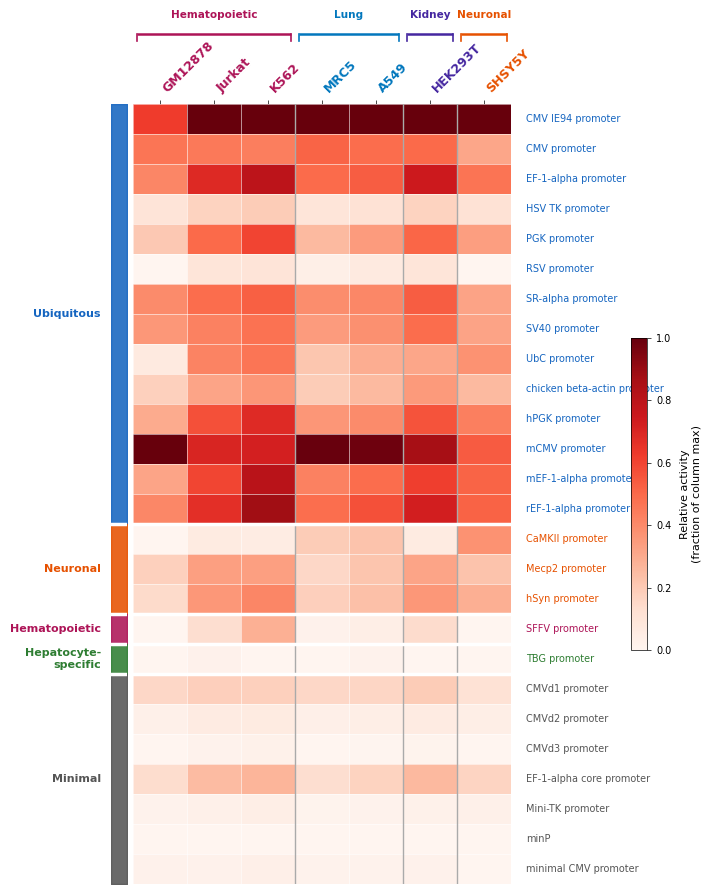

In [ ]:
import polars as pl
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from typing import Optional

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

# ── Constants ──────────────────────────────────────────────────────────────────
CELL_COLUMNS = [
    'CREST (GM12878)', 'CREST (Jurkat)', 'CREST (K562)', 'CREST (MRC5)', 'CREST (A549)',
    'CREST (HEK293T)', 'CREST (SHSY5Y)',
]
CELL_LABELS = [c.removeprefix("CREST (")[:-1] for c in CELL_COLUMNS]

CELL_GROUPS = [
    ('Hematopoietic', ['GM12878', 'Jurkat', 'K562']),
    ('Lung',          ['MRC5', 'A549']),
    ('Kidney',        ['HEK293T']),
    ('Neuronal',      ['SHSY5Y']),
]

# Per-group accent colours used for bracket lines, tick labels, and group name
# text.  Hematopoietic / Neuronal intentionally echo the matching
# CATEGORY_COLORS so the two annotation layers are visually consistent.
CELL_GROUP_COLORS = {
    'Hematopoietic': '#AD1457',
    'Lung':          '#0277BD',
    'Kidney':        '#4527A0',
    'Neuronal':      '#E65100',
}

CATEGORY_ORDER = [
    'Ubiquitous', 'Neuronal', 'Hematopoietic',
    'Hepatocyte-specific', 'Minimal',
]
CATEGORY_COLORS = {
    'Ubiquitous':          '#1565C0',
    'Neuronal':            '#E65100',
    'Hematopoietic':       '#AD1457',
    'Hepatocyte-specific': '#2E7D32',
    'Minimal':             '#555555',
}
CATEGORY_DISPLAY = {
    'Hepatocyte-specific': 'Hepatocyte-\nspecific',
}


# ── Helpers ────────────────────────────────────────────────────────────────────
def _category_blocks(categories: list[str]) -> list[tuple[str, int, int]]:
    """Run-length encode a category list → (category, row_start, row_end)."""
    blocks: list[list] = []
    for i, cat in enumerate(categories):
        if not blocks or blocks[-1][0] != cat:
            blocks.append([cat, i, i + 1])
        else:
            blocks[-1][2] = i + 1
    return [tuple(b) for b in blocks]


def _prepare(
    predictions: pl.DataFrame,
    specificity: pl.DataFrame,
) -> tuple[object, np.ndarray, list, list]:
    """Join, filter, sort, and column-normalise the activity matrix."""
    df = (
        predictions
        .join(
            specificity.select(['element_name', 'tissue_specificity_category']),
            on='element_name', how='inner',
        )
        .filter(pl.col('tissue_specificity_category') != 'Condition-dependent')
        .to_pandas()
        .assign(_rank=lambda d: d['tissue_specificity_category']
                .map({c: i for i, c in enumerate(CATEGORY_ORDER)}).fillna(99))
        .sort_values(['_rank', 'element_name'])
        .drop(columns='_rank')
        .reset_index(drop=True)
    )

    raw = df[CELL_COLUMNS].values.astype(float)

    # Divide each column by its maximum → every cell type lives in [0, 1].
    # True-zero rows remain zero; the peak promoter per column becomes 1.0.
    # No row normalisation is applied.
    col_max = np.nanmax(raw, axis=0)
    col_max[col_max == 0] = 1.0   # guard: keep all-zero columns as zeros
    norm = raw / col_max

    return (
        df,
        norm,
        df['element_name'].tolist(),
        df['tissue_specificity_category'].tolist(),
    )

# def _prepare(
#     predictions: pl.DataFrame,
#     specificity: pl.DataFrame,
# ) -> tuple[object, np.ndarray, list, list]:
#     """Join, filter, sort, and rank-normalise the activity matrix.

#     Normalisation strategy
#     ----------------------
#     For each cell-type column independently:
#       1. Rank all promoter values with ``method='min'`` so that all tied
#          bottom values (typically the large block of zeros) share rank 1
#          and therefore map to 0.0 (white).
#       2. Scale ranks linearly to [0, 1]:
#              norm = (rank − 1) / (n_rows − 1)
#          The most-active promoter per column always becomes 1.0 (darkest red).

#     No row-wise normalisation is applied; each cell type is treated
#     independently, so the colour encodes relative rank *within* a cell type.
#     """
#     df = (
#         predictions
#         .join(
#             specificity.select(['element_name', 'tissue_specificity_category']),
#             on='element_name', how='inner',
#         )
#         .filter(pl.col('tissue_specificity_category') != 'Condition-dependent')
#         .to_pandas()
#         .assign(_rank=lambda d: d['tissue_specificity_category']
#                 .map({c: i for i, c in enumerate(CATEGORY_ORDER)}).fillna(99))
#         .sort_values(['_rank', 'element_name'])
#         .drop(columns='_rank')
#         .reset_index(drop=True)
#     )

#     raw  = df[CELL_COLUMNS].values.astype(float)
#     n    = raw.shape[0]
#     norm = np.zeros_like(raw)

#     if n > 1:
#         for j in range(raw.shape[1]):
#             ranks       = rankdata(raw[:, j], method='min').astype(float)  # 1-based
#             norm[:, j]  = (ranks - 1.0) / (n - 1.0)   # → [0, 1]

#     return (
#         df,
#         norm,
#         df['element_name'].tolist(),
#         df['tissue_specificity_category'].tolist(),
#     )


# ── Main ───────────────────────────────────────────────────────────────────────
def plot_promoter_heatmap(
    promoter_predictions: pl.DataFrame,
    promoter_specificity: pl.DataFrame,
    dpi: int = 300,
) -> plt.Figure:

    df, z, names, categories = _prepare(promoter_predictions, promoter_specificity)
    blocks = _category_blocks(categories)
    n_rows, n_cols = z.shape

    # Map each cell label → column index and resolve group column spans
    label_to_col = {lbl: j for j, lbl in enumerate(CELL_LABELS)}
    cell_group_bounds: list[tuple[str, int, int]] = []
    for gname, gcells in CELL_GROUPS:
        cols = [label_to_col[c] for c in gcells if c in label_to_col]
        if cols:
            cell_group_bounds.append((gname, min(cols), max(cols) + 1))

    # label → accent colour (for tick labels)
    lbl_color = {
        lbl: CELL_GROUP_COLORS[gname]
        for gname, gcells in CELL_GROUPS
        for lbl in gcells
        if lbl in label_to_col
    }

    # ── Figure geometry (inches) ───────────────────────────────────────────────
    ROW_H, COL_W        = 0.30, 0.54
    STRIP_W, STRIP_GAP  = 0.16, 0.06
    CAT_PAD, PROM_PAD   = 1.50, 2.10
    CBAR_PAD, CBAR_W    = 1.20, 0.16   # large CBAR_PAD keeps cbar well right of labels
    TOP_M, BOT_M        = 1.10, 0.70   # extra TOP_M for bracket annotations
    L_M,   R_M          = 0.20, 0.20

    heat_w = n_cols * COL_W
    heat_h = n_rows * ROW_H
    fig_w  = L_M + CAT_PAD + STRIP_W + STRIP_GAP + heat_w + PROM_PAD + CBAR_PAD + CBAR_W + R_M
    fig_h  = BOT_M + heat_h + TOP_M

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor='white')
    fx = lambda x: x / fig_w   # noqa: E731  – inch → figure fraction
    fy = lambda y: y / fig_h   # noqa: E731

    x0_strip = L_M + CAT_PAD
    x0_heat  = x0_strip + STRIP_W + STRIP_GAP

    ax_strip = fig.add_axes([fx(x0_strip), fy(BOT_M), fx(STRIP_W), fy(heat_h)])
    ax_heat  = fig.add_axes([fx(x0_heat),  fy(BOT_M), fx(heat_w),  fy(heat_h)])
    ax_cbar  = fig.add_axes([fx(x0_heat + heat_w + CBAR_PAD),
                              fy(BOT_M + heat_h * 0.30),
                              fx(CBAR_W), fy(heat_h * 0.40)])

    # ── Heatmap ────────────────────────────────────────────────────────────────
    im = ax_heat.imshow(z, aspect='auto', cmap='Reds', interpolation='nearest',
                         vmin=0, vmax=1)

    # White minor-grid lines between cells
    for attr, n in [('x', n_cols), ('y', n_rows)]:
        getattr(ax_heat, f'set_{attr}ticks')(np.arange(n + 1) - 0.5, minor=True)
    ax_heat.grid(which='minor', color='white', linewidth=0.4, zorder=3)
    ax_heat.tick_params(which='minor', length=0)

    # Thin vertical separators between cell groups
    for _, _, c_end in cell_group_bounds[:-1]:
        ax_heat.axvline(c_end - 0.5, color='#AAAAAA', linewidth=1.0, zorder=4)

    # Thicker horizontal separators between promoter categories
    for _, r0, _ in blocks[1:]:
        ax_heat.axhline(r0 - 0.5, color='white', linewidth=2.5, zorder=5)

    # Column labels on top, tinted by their cell group
    ax_heat.xaxis.set_label_position('top')
    ax_heat.xaxis.tick_top()
    ax_heat.set_xticks(np.arange(n_cols))
    ax_heat.set_xticklabels(CELL_LABELS, rotation=45, ha='left', va='bottom',
                              fontsize=9, fontweight='bold')
    for tl in ax_heat.get_xticklabels():
        tl.set_color(lbl_color.get(tl.get_text(), '#212121'))

    ax_heat.tick_params(which='major', top=True, bottom=False,
                         left=False, right=False, length=3, width=0.5)
    ax_heat.set_yticks([])
    for sp in ax_heat.spines.values():
        sp.set_visible(False)

    # Promoter name annotations (right of heatmap, coloured by category)
    for i, (name, cat) in enumerate(zip(names, categories)):
        ax_heat.text(n_cols - 0.5 + 0.28, i, name,
                      va='center', ha='left', fontsize=7, clip_on=False,
                      color=CATEGORY_COLORS[cat])

    # ── Cell-group bracket annotations (above column labels) ──────────────────
    # All coordinates are in figure-space inches, then converted to fractions.
    # Column c occupies figure-x ∈ [x0_heat + c*COL_W, x0_heat + (c+1)*COL_W].
    Y_BRACKET = BOT_M + heat_h + 0.70   # bracket line height from figure bottom
    Y_LABEL   = BOT_M + heat_h + 0.84   # group name baseline
    INSET     = 0.04                     # horizontal margin from cell edge

    for gname, c_start, c_end in cell_group_bounds:
        x_lo  = x0_heat + c_start * COL_W + INSET
        x_hi  = x0_heat + c_end   * COL_W - INSET
        x_mid = (x_lo + x_hi) / 2
        color = CELL_GROUP_COLORS.get(gname, '#555555')

        # Horizontal spanning line
        fig.add_artist(Line2D(
            [fx(x_lo), fx(x_hi)], [fy(Y_BRACKET), fy(Y_BRACKET)],
            transform=fig.transFigure,
            color=color, linewidth=1.8, solid_capstyle='butt', clip_on=False))
        # Short descending end-ticks to form a clear bracket
        for x_end in (x_lo, x_hi):
            fig.add_artist(Line2D(
                [fx(x_end), fx(x_end)],
                [fy(Y_BRACKET - 0.07), fy(Y_BRACKET)],
                transform=fig.transFigure,
                color=color, linewidth=1.2, clip_on=False))
        # Group name
        fig.text(fx(x_mid), fy(Y_LABEL), gname,
                  ha='center', va='bottom',
                  fontsize=7.5, fontweight='bold', color=color)

    # ── Category strip ─────────────────────────────────────────────────────────
    ax_strip.set(xlim=(0, 1), ylim=(-0.5, n_rows - 0.5))
    ax_strip.invert_yaxis()
    ax_strip.axis('off')
    for cat, r0, r1 in blocks:
        ax_strip.fill_betweenx([r0 - 0.5, r1 - 0.5], 0, 1,
                                 color=CATEGORY_COLORS[cat], alpha=0.88)
        if r0 > 0:
            ax_strip.axhline(r0 - 0.5, color='white', linewidth=2.5, zorder=5)

    # Category labels to the left of the strip (figure coordinates)
    for cat, r0, r1 in blocks:
        mid = (r0 + r1 - 1) / 2
        fig.text(fx(x0_strip - 0.10),
                  fy(BOT_M + heat_h - (mid + 0.5) * ROW_H),
                  CATEGORY_DISPLAY.get(cat, cat),
                  ha='right', va='center', fontsize=8, fontweight='bold',
                  color=CATEGORY_COLORS[cat])

    # ── Colourbar ──────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.set_label('Relative activity\n(fraction of column max)', fontsize=8, labelpad=6)
    ticks = np.linspace(0, 1, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f'{v:.1f}' for v in ticks])
    cbar.ax.tick_params(labelsize=7, length=3, width=0.5)
    cbar.outline.set_linewidth(0.5)

    # # ── Colourbar ──────────────────────────────────────────────────────────────
    # cbar = fig.colorbar(im, cax=ax_cbar)
    # cbar.set_label('Promoter rank\n(within cell type)', fontsize=8, labelpad=6)
    # cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    # cbar.set_ticklabels(['0 (lowest)', '0.25', '0.5', '0.75', '1 (highest)'])
    # cbar.ax.tick_params(labelsize=7, length=3, width=0.5)
    # cbar.outline.set_linewidth(0.5)

    return fig


# ── Entry point ────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    fig = plot_promoter_heatmap(
        promoter_predictions=promoter_predictions,
        promoter_specificity=promoter_specificity,
    )
    plt.show()
